# BiLSTM Weekly Drought Classification - Kansas (Clean Baseline)

Notebook ini adalah versi rapi dari baseline Kansas dengan perbaikan utama:
- Dataset weekly terintegrasi: NASA POWER (daily -> weekly mean) + USDM weekly
- Patch leakage: fitur dibuat kausal (lag/rolling masa lalu), scaler fit hanya pada train
- Balancing hanya pada training sequences
- Hapus redundancy dari notebook awal

In [35]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [36]:
import os
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.isotonic import IsotonicRegression

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    LSTM,
    Bidirectional,
    Dropout,
    Input,
    BatchNormalization,
    MultiHeadAttention,
    LayerNormalization,
    Add,
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.21.0


In [52]:
SEED = 42
DATA_PATH = 'Integrated_weekly_KAN.csv'
OUTPUT_FOLDER = 'output_weekly_kansas_clean_expC_recover'

# Weekly setup
SEQ_LENGTH = 52
BATCH_SIZE = 64
EPOCHS = 80

# Split setup: use time-aware split with distribution matching
SPLIT_MODE = 'auto_time_stratified'  # auto_time_stratified or fixed_dates
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
MIN_WEEKS_PER_SPLIT = 52

# Used only when SPLIT_MODE='fixed_dates'
TRAIN_END_DATE = '2019-12-31'
VAL_START_DATE = '2020-01-01'
VAL_END_DATE = '2021-12-31'
TEST_START_DATE = '2022-01-01'

# Baseline metrics (from previous run) for comparison
BASELINE_MACRO_F1 = 0.59
BASELINE_D3_F1 = 0.27
BASELINE_D4_F1 = 0.00

# Boundary-focused experiment mode
EXPERIMENT_MODES = ['boundary_ce']

# Default class-weight emphasis (used as fallback)
CLASS_WEIGHT_BOOST = {
    0: 1.15,
    1: 1.65,
    2: 1.25,
    4: 2.00,
    5: 3.00,
}

# Boundary-aware loss controls (fallback defaults)
BOUNDARY_LOSS_LAMBDA = 0.12
LABEL_SMOOTHING = 0.02

# Calibration and robust thresholding (fallback defaults)
CALIBRATION_METHOD = 'temperature'  # temperature or isotonic
ROLLING_FOLDS = 8
THRESH_OPT_PASSES = 3
THRESHOLD_GRIDS = {
    0: np.round(np.arange(0.75, 1.30, 0.05), 2),
    1: np.round(np.arange(0.80, 1.40, 0.05), 2),
    2: np.round(np.arange(0.80, 1.40, 0.05), 2),
    4: np.round(np.arange(0.75, 1.10, 0.05), 2),
    5: np.round(np.arange(0.15, 0.45, 0.05), 2),
}

# Relaxed macro-first final selection with hard severe-class floors
SEVERE_GUARDRAIL_D3_MIN = 0.65
SEVERE_GUARDRAIL_D4_MIN = 0.75

# Optional conservative ROS on training sequences only (kept OFF for phase-1)
ENABLE_TRAIN_ROS = False
ROS_TARGET_MULTIPLIER = {
    3: 1.30,  # D2
    4: 1.40,  # D3
    5: 1.50,  # D4
}

# No-ROS first experiment matrix (A/B/C)
EXPERIMENT_RUNS = [
    {
        'name': 'expA_temp_lambda020_moderate_w',
        'calibration_method': 'temperature',
        'boundary_loss_lambda': 0.20,
        'rolling_folds': 8,
        'class_weight_boost': {0: 1.10, 1: 1.35, 2: 1.15, 4: 1.50, 5: 2.50},
        'threshold_grids': {
            0: np.round(np.arange(0.75, 1.30, 0.05), 2),
            1: np.round(np.arange(0.80, 1.40, 0.05), 2),
            2: np.round(np.arange(0.80, 1.40, 0.05), 2),
            4: np.round(np.arange(0.75, 1.10, 0.05), 2),
            5: np.round(np.arange(0.15, 0.45, 0.05), 2),
        },
    },
    {
        'name': 'expB_temp_lambda020_tight_thr',
        'calibration_method': 'temperature',
        'boundary_loss_lambda': 0.20,
        'rolling_folds': 8,
        'class_weight_boost': {0: 1.10, 1: 1.30, 2: 1.10, 4: 1.50, 5: 2.30},
        'threshold_grids': {
            0: np.round(np.arange(0.80, 1.25, 0.05), 2),
            1: np.round(np.arange(0.85, 1.35, 0.05), 2),
            2: np.round(np.arange(0.85, 1.35, 0.05), 2),
            4: np.round(np.arange(0.80, 1.05, 0.05), 2),
            5: np.round(np.arange(0.20, 0.40, 0.05), 2),
        },
    },
    {
        'name': 'expC_temp_lambda015_boundary_recall',
        'calibration_method': 'temperature',
        'boundary_loss_lambda': 0.15,
        'rolling_folds': 8,
        'class_weight_boost': {0: 1.05, 1: 1.25, 2: 1.10, 4: 1.40, 5: 2.20},
        'threshold_grids': {
            0: np.round(np.arange(0.80, 1.20, 0.05), 2),
            1: np.round(np.arange(0.85, 1.30, 0.05), 2),
            2: np.round(np.arange(0.85, 1.30, 0.05), 2),
            4: np.round(np.arange(0.80, 1.05, 0.05), 2),
            5: np.round(np.arange(0.20, 0.40, 0.05), 2),
        },
    },
    {
    'name': 'expD_lambda012_d0boost',
    'calibration_method': 'temperature',
    'boundary_loss_lambda': 0.12,
    'rolling_folds': 8,
    'class_weight_boost': {0: 1.70, 1: 1.40, 2: 1.15, 4: 1.80, 5: 1.80},
    'threshold_grids': {
        0: np.round(np.arange(0.75, 1.30, 0.05), 2),
        1: np.round(np.arange(0.80, 1.40, 0.05), 2),
        2: np.round(np.arange(0.80, 1.40, 0.05), 2),
        4: np.round(np.arange(0.75, 1.10, 0.05), 2),
        5: np.round(np.arange(0.15, 0.45, 0.05), 2),
        },
    },
]

# Regularization setup
L2_WEIGHT_DECAY = 1e-4
DROPOUT_LSTM_1 = 0.4
DROPOUT_LSTM_2 = 0.4
DROPOUT_DENSE = 0.3

# Training control
EARLY_STOPPING_PATIENCE = 4

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print('Config ready')
print(f'Data path: {DATA_PATH}')
print(f'Split mode: {SPLIT_MODE}')
print(f'Split ratios (train/val/test): {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}')
print(f'Min weeks per split: {MIN_WEEKS_PER_SPLIT}')
print(f'Experiment modes: {EXPERIMENT_MODES}')
print(f'Boundary loss lambda (default): {BOUNDARY_LOSS_LAMBDA}')
print(f'Calibration method (default): {CALIBRATION_METHOD}')
print(f'Rolling folds (default): {ROLLING_FOLDS}')
print(f'RUNS: {[r["name"] for r in EXPERIMENT_RUNS]}')
print(f'Enable train ROS: {ENABLE_TRAIN_ROS}')
print(f'Severe guardrail mins (D3/D4): {SEVERE_GUARDRAIL_D3_MIN}/{SEVERE_GUARDRAIL_D4_MIN}')
print(f'L2 weight decay: {L2_WEIGHT_DECAY}')
print(f'Dropout (LSTM1/LSTM2/Dense): {DROPOUT_LSTM_1}/{DROPOUT_LSTM_2}/{DROPOUT_DENSE}')
print(f'EarlyStopping patience: {EARLY_STOPPING_PATIENCE}')
print(f'Output folder: {OUTPUT_FOLDER}')

Config ready
Data path: Integrated_weekly_KAN.csv
Split mode: auto_time_stratified
Split ratios (train/val/test): 0.7/0.15/0.15
Min weeks per split: 52
Experiment modes: ['boundary_ce']
Boundary loss lambda (default): 0.12
Calibration method (default): temperature
Rolling folds (default): 8
RUNS: ['expA_temp_lambda020_moderate_w', 'expB_temp_lambda020_tight_thr', 'expC_temp_lambda015_boundary_recall', 'expD_lambda012_d0boost']
Enable train ROS: False
Severe guardrail mins (D3/D4): 0.65/0.75
L2 weight decay: 0.0001
Dropout (LSTM1/LSTM2/Dense): 0.4/0.4/0.3
EarlyStopping patience: 4
Output folder: output_weekly_kansas_clean_expC_recover


In [38]:
df = pd.read_csv(DATA_PATH)
df['week_start'] = pd.to_datetime(df['week_start'])
df['ValidEnd'] = pd.to_datetime(df['ValidEnd'])
df = df.sort_values(['FIPS', 'week_start']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Unique counties: {df["FIPS"].nunique()}')
print(f'Date range: {df["week_start"].min().date()} to {df["week_start"].max().date()}')
display(df.head())

Shape: (77748, 20)
Unique counties: 93
Date range: 2009-12-29 to 2025-12-30


,week_start,ValidEnd,Year,Month,YearWeek,FIPS,County,State,ALLSKY_SFC_SW_DWN,PRECTOTCORR,PS,RH2M,T2M,WS2M,None,D0,D1,D2,D3,D4
0,2009-12-29,2010-01-04,2009,12,200953,20001,Allen County,KS,6.424625,0.281375,96.380500,85.468625,-9.298000,2.292375,100.0,0.0,0.0,0.0,0.0,0.0
1,2010-01-05,2010-01-11,2010,1,201001,20001,Allen County,KS,8.633143,0.228143,96.308000,80.965000,-9.317357,3.441643,100.0,0.0,0.0,0.0,0.0,0.0
2,2010-01-12,2010-01-18,2010,1,201002,20001,Allen County,KS,8.845143,0.023071,95.363714,85.271071,1.079714,2.279500,100.0,0.0,0.0,0.0,0.0,0.0
3,2010-01-19,2010-01-25,2010,1,201003,20001,Allen County,KS,7.583786,0.590286,93.982071,80.399571,2.468286,4.079071,100.0,0.0,0.0,0.0,0.0,0.0
4,2010-01-26,2010-02-01,2010,1,201004,20001,Allen County,KS,8.431714,0.984714,95.652714,76.353500,-2.827214,2.809286,100.0,0.0,0.0,0.0,0.0,0.0


In [39]:
def decumulate_drought(row):
    pmf_d4 = row['D4']
    pmf_d3 = max(0.0, row['D3'] - row['D4'])
    pmf_d2 = max(0.0, row['D2'] - row['D3'])
    pmf_d1 = max(0.0, row['D1'] - row['D2'])
    pmf_d0 = max(0.0, row['D0'] - row['D1'])
    pmf_none = max(0.0, row['None'])
    return pd.Series([pmf_none, pmf_d0, pmf_d1, pmf_d2, pmf_d3, pmf_d4])

pmf_cols = ['PMF_None', 'PMF_D0', 'PMF_D1', 'PMF_D2', 'PMF_D3', 'PMF_D4']
df[pmf_cols] = df.apply(decumulate_drought, axis=1)
df['PMF_Sum'] = df[pmf_cols].sum(axis=1)
df['Label'] = df[pmf_cols].idxmax(axis=1).apply(lambda x: pmf_cols.index(x))
label_map = {0: 'None', 1: 'D0', 2: 'D1', 3: 'D2', 4: 'D3', 5: 'D4'}

print('PMF sum stats:')
display(df['PMF_Sum'].describe())

class_dist = df['Label'].value_counts().sort_index()
print('Class distribution (full data):')
for idx, cnt in class_dist.items():
    print(f'  {label_map[idx]:>4s}: {cnt}')

PMF sum stats:


count    7.774800e+04
mean     1.000000e+02
std      1.358024e-15
min      1.000000e+02
25%      1.000000e+02
50%      1.000000e+02
75%      1.000000e+02
max      1.000000e+02
Name: PMF_Sum, dtype: float64

Class distribution (full data):
  None: 33904
    D0: 15656
    D1: 11960
    D2: 7932
    D3: 5167
    D4: 3129


In [40]:
base_weather = ['ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'PS', 'RH2M', 'T2M', 'WS2M']
df_fe = df.copy().sort_values(['FIPS', 'week_start']).reset_index(drop=True)

for lag in [1, 2, 4, 8]:
    df_fe[f'PREC_lag{lag}'] = df_fe.groupby('FIPS')['PRECTOTCORR'].shift(lag)
    df_fe[f'T2M_lag{lag}'] = df_fe.groupby('FIPS')['T2M'].shift(lag)
    df_fe[f'RH2M_lag{lag}'] = df_fe.groupby('FIPS')['RH2M'].shift(lag)

for window in [4, 12]:
    df_fe[f'PREC_roll{window}_mean'] = df_fe.groupby('FIPS')['PRECTOTCORR'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    df_fe[f'PREC_roll{window}_std'] = df_fe.groupby('FIPS')['PRECTOTCORR'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0.0))
    df_fe[f'T2M_roll{window}_mean'] = df_fe.groupby('FIPS')['T2M'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())

iso_week = df_fe['week_start'].dt.isocalendar().week.astype(int)
df_fe['week_sin'] = np.sin(2 * np.pi * iso_week / 52.0)
df_fe['week_cos'] = np.cos(2 * np.pi * iso_week / 52.0)

for col in ['D1', 'D2', 'D3', 'D4']:
    df_fe[f'{col}_lag1'] = df_fe.groupby('FIPS')[col].shift(1)

df_fe['drought_carryover_lag1'] = df_fe['D1_lag1'] + 0.5 * df_fe['D2_lag1']
df_fe['severe_carryover_lag1'] = df_fe['D3_lag1'] + df_fe['D4_lag1']
df_fe['heat_dry_stress'] = df_fe['T2M'] * (1.0 - df_fe['RH2M'] / 100.0)

feature_cols = [
    'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'PS', 'RH2M', 'T2M', 'WS2M',
    'PREC_lag1', 'PREC_lag2', 'PREC_lag4', 'PREC_lag8',
    'T2M_lag1', 'T2M_lag2', 'T2M_lag4', 'T2M_lag8',
    'RH2M_lag1', 'RH2M_lag2', 'RH2M_lag4', 'RH2M_lag8',
    'PREC_roll4_mean', 'PREC_roll4_std', 'PREC_roll12_mean', 'PREC_roll12_std',
    'T2M_roll4_mean', 'T2M_roll12_mean',
    'week_sin', 'week_cos',
    'drought_carryover_lag1', 'severe_carryover_lag1', 'heat_dry_stress'
]

before_drop = len(df_fe)
df_fe = df_fe.dropna(subset=feature_cols + ['Label']).reset_index(drop=True)
print(f'Rows before dropna: {before_drop:,}')
print(f'Rows after dropna:  {len(df_fe):,}')
print(f'Feature count: {len(feature_cols)}')

Rows before dropna: 77,748
Rows after dropna:  77,004
Feature count: 29


In [41]:
def normalized_counts(y, n_classes=6):
    counts = np.bincount(y.astype(int), minlength=n_classes).astype(np.float64)
    total = counts.sum()
    return counts / total if total > 0 else np.zeros(n_classes, dtype=np.float64)


def js_divergence(p, q, eps=1e-12):
    p = np.clip(p, eps, 1.0)
    q = np.clip(q, eps, 1.0)
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)
    kl_pm = np.sum(p * np.log(p / m))
    kl_qm = np.sum(q * np.log(q / m))
    return 0.5 * (kl_pm + kl_qm)


def choose_time_stratified_cutoffs(df_input, label_col='Label', week_col='week_start'):
    weeks = np.array(sorted(df_input[week_col].unique()))
    n_weeks = len(weeks)
    if n_weeks < 3 * MIN_WEEKS_PER_SPLIT:
        raise ValueError(f'Not enough weeks ({n_weeks}) for requested MIN_WEEKS_PER_SPLIT={MIN_WEEKS_PER_SPLIT}.')

    train_idx_min = MIN_WEEKS_PER_SPLIT
    train_idx_max = n_weeks - 2 * MIN_WEEKS_PER_SPLIT

    best = None

    for train_end_idx in range(train_idx_min, train_idx_max + 1):
        val_end_idx_min = train_end_idx + MIN_WEEKS_PER_SPLIT
        val_end_idx_max = n_weeks - MIN_WEEKS_PER_SPLIT
        for val_end_idx in range(val_end_idx_min, val_end_idx_max + 1):
            train_end = weeks[train_end_idx - 1]
            val_end = weeks[val_end_idx - 1]

            train_mask = df_input[week_col] <= train_end
            val_mask = (df_input[week_col] > train_end) & (df_input[week_col] <= val_end)
            test_mask = df_input[week_col] > val_end

            y_train = df_input.loc[train_mask, label_col].values
            y_val = df_input.loc[val_mask, label_col].values
            y_test = df_input.loc[test_mask, label_col].values

            if len(y_train) == 0 or len(y_val) == 0 or len(y_test) == 0:
                continue

            p_train = normalized_counts(y_train)
            p_val = normalized_counts(y_val)
            p_test = normalized_counts(y_test)

            js_tv = js_divergence(p_train, p_val)
            js_tt = js_divergence(p_train, p_test)

            missing_penalty = 0.0
            for cls in range(6):
                if p_train[cls] > 0.01 and (p_val[cls] == 0 or p_test[cls] == 0):
                    missing_penalty += 1.0

            ratio_penalty = (
                abs(train_end_idx / n_weeks - TRAIN_RATIO)
                + abs((val_end_idx - train_end_idx) / n_weeks - VAL_RATIO)
                + abs((n_weeks - val_end_idx) / n_weeks - TEST_RATIO)
            )

            score = (1.0 * js_tv) + (0.75 * js_tt) + (1.5 * missing_penalty) + (0.25 * ratio_penalty)

            if best is None or score < best['score']:
                best = {
                    'score': score,
                    'train_end': train_end,
                    'val_end': val_end,
                    'train_weeks': train_end_idx,
                    'val_weeks': val_end_idx - train_end_idx,
                    'test_weeks': n_weeks - val_end_idx,
                    'js_train_val': js_tv,
                    'js_train_test': js_tt,
                }

    if best is None:
        raise RuntimeError('Unable to find valid split cutoffs.')

    return best


if SPLIT_MODE == 'fixed_dates':
    train_df = df_fe[df_fe['week_start'] <= TRAIN_END_DATE].copy()
    val_df = df_fe[(df_fe['week_start'] >= VAL_START_DATE) & (df_fe['week_start'] <= VAL_END_DATE)].copy()
    test_df = df_fe[df_fe['week_start'] >= TEST_START_DATE].copy()
    split_meta = {
        'mode': 'fixed_dates',
        'train_end': pd.to_datetime(TRAIN_END_DATE),
        'val_end': pd.to_datetime(VAL_END_DATE),
        'js_train_val': np.nan,
        'js_train_test': np.nan,
    }
else:
    best_split = choose_time_stratified_cutoffs(df_fe, label_col='Label', week_col='week_start')
    train_end = best_split['train_end']
    val_end = best_split['val_end']

    train_df = df_fe[df_fe['week_start'] <= train_end].copy()
    val_df = df_fe[(df_fe['week_start'] > train_end) & (df_fe['week_start'] <= val_end)].copy()
    test_df = df_fe[df_fe['week_start'] > val_end].copy()

    split_meta = {
        'mode': SPLIT_MODE,
        'train_end': train_end,
        'val_end': val_end,
        'js_train_val': best_split['js_train_val'],
        'js_train_test': best_split['js_train_test'],
        'train_weeks': best_split['train_weeks'],
        'val_weeks': best_split['val_weeks'],
        'test_weeks': best_split['test_weeks'],
    }

print(f"Train rows: {len(train_df):,}")
print(f"Val rows:   {len(val_df):,}")
print(f"Test rows:  {len(test_df):,}")
print(f"Split mode: {split_meta['mode']}")
print(f"Train end:  {pd.to_datetime(split_meta['train_end']).date()}")
print(f"Val end:    {pd.to_datetime(split_meta['val_end']).date()}")
if not np.isnan(split_meta['js_train_val']):
    print(f"JS(train,val):  {split_meta['js_train_val']:.4f}")
    print(f"JS(train,test): {split_meta['js_train_test']:.4f}")

for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = split_df['Label'].value_counts().sort_index()
    total = len(split_df)
    print(f"\n{split_name} class distribution:")
    for idx in range(6):
        count = int(dist.get(idx, 0))
        ratio = (count / total) if total else 0.0
        print(f"  {label_map[idx]:>4s}: {count:6d} ({ratio:.2%})")

# Hard check against accidental temporal leakage
if train_df['week_start'].max() >= val_df['week_start'].min():
    print('WARNING: train and val ranges overlap.')
if val_df['week_start'].max() >= test_df['week_start'].min():
    print('WARNING: val and test ranges overlap.')

Train rows: 53,010
Val rows:   10,323
Test rows:  13,671
Split mode: auto_time_stratified
Train end:  2021-01-19
Val end:    2023-03-07
JS(train,val):  0.0087
JS(train,test): 0.0183

Train class distribution:
  None:  24898 (46.97%)
    D0:  10252 (19.34%)
    D1:   7112 (13.42%)
    D2:   5423 (10.23%)
    D3:   3525 (6.65%)
    D4:   1800 (3.40%)

Val class distribution:
  None:   3975 (38.51%)
    D0:   1892 (18.33%)
    D1:   1550 (15.02%)
    D2:   1114 (10.79%)
    D3:    936 (9.07%)
    D4:    856 (8.29%)

Test class distribution:
  None:   4287 (31.36%)
    D0:   3512 (25.69%)
    D1:   3298 (24.12%)
    D2:   1395 (10.20%)
    D3:    706 (5.16%)
    D4:    473 (3.46%)


In [42]:
scaler = MinMaxScaler()
scaler.fit(train_df[feature_cols])

for split_df in [train_df, val_df, test_df]:
    split_df.loc[:, feature_cols] = scaler.transform(split_df[feature_cols])

print('Scaling done using train-only fit.')

Scaling done using train-only fit.


In [43]:
def create_all_sequences(df_input, feature_columns, label_col, seq_length=52, id_col='FIPS'):
    X, y, y_date = [], [], []
    for _, group in df_input.groupby(id_col):
        group = group.sort_values('week_start')
        feats = group[feature_columns].values
        labels = group[label_col].values
        dates = group['week_start'].values
        if len(group) < seq_length:
            continue
        for i in range(len(group) - seq_length + 1):
            end_idx = i + seq_length - 1
            X.append(feats[i:i + seq_length])
            y.append(labels[end_idx])
            y_date.append(dates[end_idx])
    return np.array(X), np.array(y), np.array(y_date)


# Build continuous per-county timeline after train-only scaling.
df_scaled = pd.concat([
    train_df[['FIPS', 'week_start', 'Label'] + feature_cols],
    val_df[['FIPS', 'week_start', 'Label'] + feature_cols],
    test_df[['FIPS', 'week_start', 'Label'] + feature_cols],
], axis=0).sort_values(['FIPS', 'week_start']).reset_index(drop=True)

X_all_seq, y_all_seq, y_all_date = create_all_sequences(df_scaled, feature_cols, 'Label', SEQ_LENGTH)

train_cut = pd.to_datetime(split_meta['train_end']).to_datetime64()
val_cut = pd.to_datetime(split_meta['val_end']).to_datetime64()

train_mask = y_all_date <= train_cut
val_mask = (y_all_date > train_cut) & (y_all_date <= val_cut)
test_mask = y_all_date > val_cut

X_train_seq, y_train_seq, y_train_date = X_all_seq[train_mask], y_all_seq[train_mask], y_all_date[train_mask]
X_val_seq, y_val_seq, y_val_date = X_all_seq[val_mask], y_all_seq[val_mask], y_all_date[val_mask]
X_test_seq, y_test, y_test_date = X_all_seq[test_mask], y_all_seq[test_mask], y_all_date[test_mask]

print(f'X_train_seq: {X_train_seq.shape}')
print(f'X_val_seq:   {X_val_seq.shape}')
print(f'X_test_seq:  {X_test_seq.shape}')
print(f'Train distribution: {Counter(y_train_seq)}')
print(f'Val distribution:   {Counter(y_val_seq)}')
print(f'Test distribution:  {Counter(y_test)}')
print(f'Val period for threshold CV: {pd.to_datetime(y_val_date.min()).date()} to {pd.to_datetime(y_val_date.max()).date()}')

split_dates = {
    'train_max': train_df['week_start'].max(),
    'val_min': val_df['week_start'].min(),
    'val_max': val_df['week_start'].max(),
    'test_min': test_df['week_start'].min(),
}
print('\nSplit boundary check:')
print(split_dates)
if split_dates['train_max'] >= split_dates['val_min']:
    print('WARNING: train and val date ranges overlap.')
if split_dates['val_max'] >= split_dates['test_min']:
    print('WARNING: val and test date ranges overlap.')

X_train_seq: (48267, 52, 29)
X_val_seq:   (10323, 52, 29)
X_test_seq:  (13671, 52, 29)
Train distribution: Counter({np.int64(0): 21177, np.int64(1): 9563, np.int64(2): 6797, np.int64(3): 5405, np.int64(4): 3525, np.int64(5): 1800})
Val distribution:   Counter({np.int64(0): 3975, np.int64(1): 1892, np.int64(2): 1550, np.int64(3): 1114, np.int64(4): 936, np.int64(5): 856})
Test distribution:  Counter({np.int64(0): 4287, np.int64(1): 3512, np.int64(2): 3298, np.int64(3): 1395, np.int64(4): 706, np.int64(5): 473})
Val period for threshold CV: 2021-01-26 to 2023-03-07

Split boundary check:
{'train_max': Timestamp('2021-01-19 00:00:00'), 'val_min': Timestamp('2021-01-26 00:00:00'), 'val_max': Timestamp('2023-03-07 00:00:00'), 'test_min': Timestamp('2023-03-14 00:00:00')}


In [44]:
# Preserve original sequence distribution (no ROS / synthetic sampling)
n_samples, n_steps, n_features = X_train_seq.shape
X_train_model = X_train_seq
y_train_model = y_train_seq

print('Oversampling disabled. Using original training distribution.')
print(f'Train shape: {X_train_model.shape}')
print(f'Train distribution: {Counter(y_train_model)}')

classes = np.arange(6)
base_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_model.astype(int),
)
base_class_weight_dict = {int(c): float(w) for c, w in zip(classes, base_weights_arr)}

boosted_class_weight_dict = base_class_weight_dict.copy()
for cls, mult in CLASS_WEIGHT_BOOST.items():
    boosted_class_weight_dict[int(cls)] = boosted_class_weight_dict[int(cls)] * float(mult)

print('Base class weights:', base_class_weight_dict)
print('Boosted class weights:', boosted_class_weight_dict)

Oversampling disabled. Using original training distribution.
Train shape: (48267, 52, 29)
Train distribution: Counter({np.int64(0): 21177, np.int64(1): 9563, np.int64(2): 6797, np.int64(3): 5405, np.int64(4): 3525, np.int64(5): 1800})
Base class weights: {0: 0.37986966992491855, 1: 0.8412109170762313, 2: 1.18353685449463, 3: 1.4883441258094356, 4: 2.282127659574468, 5: 4.469166666666666}
Boosted class weights: {0: 0.4368501204136563, 1: 1.3879980131757816, 2: 1.4794210681182876, 3: 1.4883441258094356, 4: 4.564255319148936, 5: 13.407499999999999}


In [45]:
num_classes = 6

def to_ordinal_targets(y_idx, n_classes=6):
    y_idx = np.asarray(y_idx).astype(int)
    out = np.zeros((len(y_idx), n_classes), dtype=np.float32)
    for i, cls in enumerate(y_idx):
        out[i, : cls + 1] = 1.0
    return out


y_train_ord = to_ordinal_targets(y_train_model, n_classes=num_classes)
y_val_ord = to_ordinal_targets(y_val_seq, n_classes=num_classes)
y_test_ord = to_ordinal_targets(y_test, n_classes=num_classes)


def build_attention_model(seq_length, n_features, n_classes):
    reg = l2(L2_WEIGHT_DECAY)

    inp = Input(shape=(seq_length, n_features))
    x = Bidirectional(
        LSTM(128, return_sequences=True, kernel_regularizer=reg, recurrent_regularizer=reg)
    )(inp)
    x = BatchNormalization()(x)
    x = Dropout(DROPOUT_LSTM_1)(x)

    attn = MultiHeadAttention(num_heads=2, key_dim=32, dropout=0.10)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    x = Bidirectional(
        LSTM(64, kernel_regularizer=reg, recurrent_regularizer=reg)
    )(x)
    x = BatchNormalization()(x)
    x = Dropout(DROPOUT_LSTM_2)(x)

    emb = Dense(96, activation='relu', kernel_regularizer=reg, name='embedding_vec')(x)
    emb = Dropout(DROPOUT_DENSE)(emb)
    logits = Dense(n_classes, activation=None, kernel_regularizer=reg, name='ordinal_logits')(emb)

    # Concatenate logits and embedding so a single custom loss can access both.
    out = tf.keras.layers.Concatenate(name='joint_output')([logits, emb])
    model = Model(inputs=inp, outputs=out)
    return model


def make_boundary_cost_matrix(n_classes=6):
    cm = np.zeros((n_classes, n_classes), dtype=np.float32)

    for i in range(n_classes):
        for j in range(n_classes):
            if i == j:
                continue
            cm[i, j] = 0.05 * abs(i - j)

    cm[0, 1] = 1.6
    cm[1, 0] = 1.4
    cm[1, 2] = 1.0
    cm[2, 1] = 0.9
    cm[0, 2] = 0.7
    cm[2, 0] = 0.7
    return cm


def split_joint_output(y_pred_joint, n_classes=6):
    logits = y_pred_joint[:, :n_classes]
    emb = y_pred_joint[:, n_classes:]
    return logits, emb


def ordinal_logits_to_class_probs_tf(logits):
    # Cumulative probabilities for y >= k with TF-compatible monotonic projection.
    cum = tf.sigmoid(logits)
    parts = [cum[:, :1]]
    prev = cum[:, :1]
    for j in range(1, num_classes):
        cur = tf.minimum(cum[:, j:j + 1], prev)
        parts.append(cur)
        prev = cur
    cum_mon = tf.concat(parts, axis=1)

    diffs = cum_mon[:, :-1] - cum_mon[:, 1:]
    last = cum_mon[:, -1:]
    probs = tf.concat([diffs, last], axis=1)
    probs = tf.clip_by_value(probs, 1e-8, 1.0)
    probs = probs / tf.reduce_sum(probs, axis=1, keepdims=True)
    return probs


def ordinal_logits_to_class_probs_np(logits_np):
    cum = 1.0 / (1.0 + np.exp(-np.asarray(logits_np, dtype=np.float64)))
    cum_mon = cum.copy()
    for j in range(1, cum_mon.shape[1]):
        cum_mon[:, j] = np.minimum(cum_mon[:, j], cum_mon[:, j - 1])

    probs = np.zeros_like(cum_mon, dtype=np.float64)
    probs[:, :-1] = cum_mon[:, :-1] - cum_mon[:, 1:]
    probs[:, -1] = cum_mon[:, -1]
    probs = np.clip(probs, 1e-8, None)
    probs = probs / probs.sum(axis=1, keepdims=True)
    return probs


def boundary_pair_triplet_loss(emb, labels, anchor_cls, negative_cls, margin=0.3):
    anchor_idx = tf.where(tf.equal(labels, int(anchor_cls)))[:, 0]
    negative_idx = tf.where(tf.equal(labels, int(negative_cls)))[:, 0]

    n_anchor = tf.shape(anchor_idx)[0]
    n_negative = tf.shape(negative_idx)[0]

    def no_triplet():
        return tf.constant(0.0, dtype=tf.float32)

    def has_triplet():
        anchor = tf.gather(emb, anchor_idx)
        positive = tf.roll(anchor, shift=1, axis=0)
        negative_pool = tf.gather(emb, negative_idx)

        d_an_all = tf.norm(anchor[:, None, :] - negative_pool[None, :, :], axis=-1)
        nearest_neg_idx = tf.argmin(d_an_all, axis=1, output_type=tf.int32)
        negative = tf.gather(negative_pool, nearest_neg_idx)

        d_ap = tf.norm(anchor - positive, axis=-1)
        d_an = tf.norm(anchor - negative, axis=-1)
        return tf.reduce_mean(tf.nn.relu(d_ap - d_an + float(margin)))

    return tf.cond(
        tf.logical_and(n_anchor >= 2, n_negative >= 1),
        has_triplet,
        no_triplet,
    )


def make_ordinal_boundary_contrastive_loss(
    cost_matrix,
    loss_lambda=0.20,
    contrastive_margin=0.30,
    main_weight=0.85,
    contrastive_weight=0.15,
):
    cost_t = tf.constant(cost_matrix, dtype=tf.float32)

    def loss_fn(y_true_ord, y_pred_joint):
        logits, emb = split_joint_output(y_pred_joint, n_classes=num_classes)
        y_true_ord = tf.cast(y_true_ord, tf.float32)

        bce_each = tf.nn.sigmoid_cross_entropy_with_logits(labels=y_true_ord, logits=logits)
        bce_main = tf.reduce_mean(bce_each, axis=-1)

        probs = ordinal_logits_to_class_probs_tf(logits)
        y_true_cls = tf.cast(tf.reduce_sum(y_true_ord, axis=1) - 1.0, tf.int32)
        y_true_1h = tf.one_hot(y_true_cls, depth=num_classes, dtype=tf.float32)
        expected_cost = tf.reduce_sum(tf.matmul(y_true_1h, cost_t) * probs, axis=-1)

        main_boundary_ce_loss = bce_main + float(loss_lambda) * expected_cost

        # Only boundary pairs are constrained: (None,D0) and (D0,D1).
        c01 = boundary_pair_triplet_loss(emb, y_true_cls, anchor_cls=1, negative_cls=0, margin=contrastive_margin)
        c12 = boundary_pair_triplet_loss(emb, y_true_cls, anchor_cls=2, negative_cls=1, margin=contrastive_margin)
        contrastive_loss = 0.5 * (c01 + c12)

        return float(main_weight) * main_boundary_ce_loss + float(contrastive_weight) * contrastive_loss

    return loss_fn


def ordinal_joint_accuracy(y_true_ord, y_pred_joint):
    logits, _ = split_joint_output(y_pred_joint, n_classes=num_classes)
    probs = ordinal_logits_to_class_probs_tf(logits)
    y_pred_cls = tf.argmax(probs, axis=1, output_type=tf.int32)
    y_true_cls = tf.cast(tf.reduce_sum(y_true_ord, axis=1) - 1.0, tf.int32)
    return tf.reduce_mean(tf.cast(tf.equal(y_true_cls, y_pred_cls), tf.float32))


def make_callbacks(tag):
    return [
        EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'{OUTPUT_FOLDER}/best_model_{tag}.keras', monitor='val_loss', save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ]


def predict_class_probs(model_obj, x_input):
    y_joint = model_obj.predict(x_input, verbose=0)
    y_logits = y_joint[:, :num_classes]
    return ordinal_logits_to_class_probs_np(y_logits)


def safe_normalize_probs(prob):
    prob = np.clip(prob, 1e-8, None)
    prob = prob / prob.sum(axis=1, keepdims=True)
    return prob


def fit_isotonic_calibrators(prob, y_true, n_classes=6):
    calibrators = []
    for cls_idx in range(n_classes):
        y_bin = (y_true == cls_idx).astype(int)
        if y_bin.min() == y_bin.max():
            calibrators.append(None)
            continue

        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(prob[:, cls_idx], y_bin)
        calibrators.append(iso)

    return calibrators


def apply_isotonic_calibrators(prob, calibrators):
    out = np.zeros_like(prob, dtype=np.float64)
    for cls_idx, cal in enumerate(calibrators):
        if cal is None:
            out[:, cls_idx] = prob[:, cls_idx]
        else:
            out[:, cls_idx] = cal.transform(prob[:, cls_idx])
    return safe_normalize_probs(out)


def apply_temperature_scalar(prob, temp):
    temp = max(float(temp), 1e-6)
    logp = np.log(np.clip(prob, 1e-12, 1.0))
    scaled = np.exp(logp / temp)
    return safe_normalize_probs(scaled)


def fit_temperature_scalar(prob, y_true, temp_grid=None):
    if temp_grid is None:
        temp_grid = np.round(np.arange(0.70, 2.05, 0.05), 2)

    best_t = 1.0
    best_nll = np.inf

    for t in temp_grid:
        p_t = apply_temperature_scalar(prob, t)
        nll = -np.mean(np.log(np.clip(p_t[np.arange(len(y_true)), y_true.astype(int)], 1e-12, 1.0)))
        if nll < best_nll:
            best_nll = float(nll)
            best_t = float(t)

    return best_t


def fit_calibrator(prob, y_true, method='temperature', n_classes=6):
    if method == 'isotonic':
        return {'method': 'isotonic', 'params': fit_isotonic_calibrators(prob, y_true, n_classes=n_classes)}
    if method == 'temperature':
        return {'method': 'temperature', 'params': fit_temperature_scalar(prob, y_true)}
    raise ValueError(f'Unknown calibration method: {method}')


def apply_calibrator(prob, calibrator):
    if calibrator['method'] == 'isotonic':
        return apply_isotonic_calibrators(prob, calibrator['params'])
    if calibrator['method'] == 'temperature':
        return apply_temperature_scalar(prob, calibrator['params'])
    raise ValueError(f"Unknown calibrator method: {calibrator['method']}")


def build_rolling_origin_folds(date_array, n_folds=4, min_train_frac=0.35):
    dates = pd.Series(pd.to_datetime(date_array)).reset_index(drop=True)
    unique_dates = np.array(sorted(dates.unique()))

    if len(unique_dates) < 8:
        return []

    start_idx = max(int(round(len(unique_dates) * min_train_frac)), 1)
    remaining = len(unique_dates) - start_idx
    if remaining <= 1:
        return []

    k = min(int(n_folds), remaining)
    window = max(1, remaining // k)

    folds = []
    for fold_idx in range(k):
        eval_start_idx = start_idx + fold_idx * window
        eval_end_idx = start_idx + (fold_idx + 1) * window if fold_idx < k - 1 else len(unique_dates)

        if eval_start_idx >= len(unique_dates):
            continue

        eval_start_date = unique_dates[eval_start_idx]
        eval_end_date = unique_dates[max(eval_start_idx, eval_end_idx - 1)]

        train_mask = (dates < eval_start_date).values
        eval_mask = ((dates >= eval_start_date) & (dates <= eval_end_date)).values

        if train_mask.sum() == 0 or eval_mask.sum() == 0:
            continue

        folds.append({
            'train_mask': train_mask,
            'eval_mask': eval_mask,
            'eval_start': pd.to_datetime(eval_start_date),
            'eval_end': pd.to_datetime(eval_end_date),
        })

    return folds


def rolling_calibration_oof(prob, y_true, date_array, method='temperature', n_classes=6, n_folds=4):
    folds = build_rolling_origin_folds(date_array, n_folds=n_folds)
    oof_cal = np.full(prob.shape, np.nan, dtype=np.float64)
    used_mask = np.zeros(len(y_true), dtype=bool)

    for fold in folds:
        tr = fold['train_mask']
        ev = fold['eval_mask']
        cal = fit_calibrator(prob[tr], y_true[tr], method=method, n_classes=n_classes)
        oof_cal[ev] = apply_calibrator(prob[ev], cal)
        used_mask[ev] = True

    return oof_cal, used_mask, folds


def apply_thresholds_multiclass(prob, thresholds):
    adjusted = prob.copy()
    for cls_idx, thr in thresholds.items():
        adjusted[:, int(cls_idx)] = adjusted[:, int(cls_idx)] / max(float(thr), 1e-6)
    return np.argmax(adjusted, axis=1)


def boundary_objective(y_true, y_pred):
    macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_per = f1_score(y_true, y_pred, labels=list(range(6)), average=None, zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(6)))
    den_01 = max(cm[0].sum() + cm[1].sum(), 1)
    den_12 = max(cm[1].sum() + cm[2].sum(), 1)
    pair_err_01 = (cm[0, 1] + cm[1, 0]) / den_01
    pair_err_12 = (cm[1, 2] + cm[2, 1]) / den_12

    objective = macro + 0.08 * f1_per[4] + 0.10 * f1_per[5] - 0.30 * pair_err_01 - 0.15 * pair_err_12

    return {
        'objective': float(objective),
        'macro_f1': float(macro),
        'f1_per': f1_per,
        'pair_err_01': float(pair_err_01),
        'pair_err_12': float(pair_err_12),
    }


def tune_thresholds_rolling(y_true, prob_cal, folds, threshold_grids, n_passes=3):
    thresholds = {int(cls): 1.0 for cls in threshold_grids.keys()}

    if len(folds) == 0:
        return thresholds, pd.DataFrame()

    for _ in range(int(n_passes)):
        for cls_idx, grid in threshold_grids.items():
            best_thr = thresholds[int(cls_idx)]
            best_score = -np.inf

            for thr in grid:
                trial = thresholds.copy()
                trial[int(cls_idx)] = float(thr)

                fold_scores = []
                for fold in folds:
                    ev = fold['eval_mask']
                    y_hat = apply_thresholds_multiclass(prob_cal[ev], trial)
                    fold_scores.append(boundary_objective(y_true[ev], y_hat)['objective'])

                mean_score = float(np.mean(fold_scores))
                if mean_score > best_score:
                    best_score = mean_score
                    best_thr = float(thr)

            thresholds[int(cls_idx)] = best_thr

    diag_rows = []
    for fold_id, fold in enumerate(folds, start=1):
        ev = fold['eval_mask']
        y_hat = apply_thresholds_multiclass(prob_cal[ev], thresholds)
        obj = boundary_objective(y_true[ev], y_hat)
        diag_rows.append({
            'fold': fold_id,
            'eval_start': fold['eval_start'].date(),
            'eval_end': fold['eval_end'].date(),
            'macro_f1': obj['macro_f1'],
            'pair_err_01': obj['pair_err_01'],
            'pair_err_12': obj['pair_err_12'],
            'objective': obj['objective'],
        })

    return thresholds, pd.DataFrame(diag_rows)


def top_confusion_pairs(y_true, y_pred, top_k=6):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(6)))
    pairs = []
    for i in range(6):
        for j in range(6):
            if i == j:
                continue
            pairs.append((int(i), int(j), int(cm[i, j])))
    pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
    return pairs[:top_k], cm


train_sample_weight = np.array([
    boosted_class_weight_dict[int(c)] for c in y_train_model
], dtype=np.float32)

print('Ordinal + boundary-contrastive model utilities ready.')
print(f'Contrastive targets: (None,D0) and (D0,D1), margin=0.30')
print(f'Train sample-weight stats: min={train_sample_weight.min():.4f}, max={train_sample_weight.max():.4f}, mean={train_sample_weight.mean():.4f}')

Ordinal + boundary-contrastive model utilities ready.
Contrastive targets: (None,D0) and (D0,D1), margin=0.30
Train sample-weight stats: min=0.4369, max=13.4075, mean=1.6750


In [46]:
def summarize_predictions(y_true, y_pred):
    macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    acc = accuracy_score(y_true, y_pred)

    pr, rc, f1c, sup = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(6)),
        zero_division=0,
    )

    class_table = pd.DataFrame({
        'class_idx': list(range(6)),
        'class_name': [label_map[i] for i in range(6)],
        'precision': pr,
        'recall': rc,
        'f1': f1c,
        'support': sup,
    })

    cm = confusion_matrix(y_true, y_pred, labels=list(range(6)))

    return {
        'macro': float(macro),
        'weighted': float(weighted),
        'accuracy': float(acc),
        'class_table': class_table,
        'cm': cm,
    }


def get_class_f1(summary_obj, class_idx):
    row = summary_obj['class_table'].loc[summary_obj['class_table']['class_idx'] == int(class_idx), 'f1']
    return float(row.iloc[0]) if len(row) > 0 else 0.0


def boundary_avg_from_summary(summary_obj):
    return (
        get_class_f1(summary_obj, 0)
        + get_class_f1(summary_obj, 1)
        + get_class_f1(summary_obj, 2)
    ) / 3.0


def stage_row(variant_name, summary_obj):
    none_f1 = get_class_f1(summary_obj, 0)
    d0_f1 = get_class_f1(summary_obj, 1)
    d1_f1 = get_class_f1(summary_obj, 2)
    d2_f1 = get_class_f1(summary_obj, 3)
    d3_f1 = get_class_f1(summary_obj, 4)
    d4_f1 = get_class_f1(summary_obj, 5)
    boundary_avg = (none_f1 + d0_f1 + d1_f1) / 3.0

    return {
        'Variant': variant_name,
        'Macro F1': float(summary_obj['macro']),
        'None F1': none_f1,
        'D0 F1': d0_f1,
        'D1 F1': d1_f1,
        'D2 F1': d2_f1,
        'D3 F1': d3_f1,
        'D4 F1': d4_f1,
        'Boundary avg (None+D0+D1)/3': boundary_avg,
    }


def severe_guardrail_pass(summary_obj):
    d3_f1 = get_class_f1(summary_obj, 4)
    d4_f1 = get_class_f1(summary_obj, 5)
    return (d3_f1 >= SEVERE_GUARDRAIL_D3_MIN) and (d4_f1 >= SEVERE_GUARDRAIL_D4_MIN)


def make_sample_weights(y_idx, boost_map):
    boosted = base_class_weight_dict.copy()
    for cls, mult in boost_map.items():
        boosted[int(cls)] = float(boosted[int(cls)]) * float(mult)
    w = np.array([boosted[int(c)] for c in y_idx], dtype=np.float32)
    return boosted, w


def maybe_apply_train_ros(X_in, y_in, sample_w_in, target_multiplier, enabled=False):
    if not enabled:
        return X_in, y_in, sample_w_in, {'enabled': False, 'added': 0}

    rng = np.random.default_rng(SEED)
    X_list = [X_in]
    y_list = [y_in]
    w_list = [sample_w_in]

    counts = Counter(y_in.astype(int))
    added = 0

    for cls, mult in target_multiplier.items():
        cls = int(cls)
        if cls not in counts or counts[cls] <= 0:
            continue
        target = int(round(counts[cls] * float(mult)))
        need = max(0, target - counts[cls])
        if need == 0:
            continue

        idx = np.where(y_in.astype(int) == cls)[0]
        sampled_idx = rng.choice(idx, size=need, replace=True)
        X_list.append(X_in[sampled_idx])
        y_list.append(y_in[sampled_idx])
        w_list.append(sample_w_in[sampled_idx])
        added += need

    X_out = np.concatenate(X_list, axis=0)
    y_out = np.concatenate(y_list, axis=0)
    w_out = np.concatenate(w_list, axis=0)

    order = rng.permutation(len(y_out))
    X_out = X_out[order]
    y_out = y_out[order]
    w_out = w_out[order]

    return X_out, y_out, w_out, {'enabled': True, 'added': int(added), 'final_size': int(len(y_out))}


def run_boundary_experiment(exp_cfg):
    exp_name = exp_cfg['name']
    calibration_method = exp_cfg.get('calibration_method', CALIBRATION_METHOD)
    boundary_loss_lambda = float(exp_cfg.get('boundary_loss_lambda', BOUNDARY_LOSS_LAMBDA))
    rolling_folds = int(exp_cfg.get('rolling_folds', ROLLING_FOLDS))
    threshold_grids = exp_cfg.get('threshold_grids', THRESHOLD_GRIDS)
    boost_map = exp_cfg.get('class_weight_boost', CLASS_WEIGHT_BOOST)

    print('\n' + '=' * 88)
    print(f'Training run: {exp_name}')
    print('Setup: ordinal BCE(logits) + boundary contrastive + calibration + rolling threshold CV')
    print('=' * 88)

    boosted_weights, train_w = make_sample_weights(y_train_model, boost_map)

    X_train_fit, y_train_fit, w_fit, ros_info = maybe_apply_train_ros(
        X_train_model,
        y_train_model,
        train_w,
        target_multiplier=ROS_TARGET_MULTIPLIER,
        enabled=ENABLE_TRAIN_ROS,
    )
    y_train_fit_ord = to_ordinal_targets(y_train_fit, n_classes=num_classes)

    print(f'Class weight boost used: {boost_map}')
    print(f'Boosted class weights: {boosted_weights}')
    print(f'ROS info: {ros_info}')
    print(f'Train fit shape: {X_train_fit.shape}, label distribution: {Counter(y_train_fit)}')

    model_local = build_attention_model(SEQ_LENGTH, n_features, num_classes)
    boundary_cost = make_boundary_cost_matrix(num_classes)
    loss_fn = make_ordinal_boundary_contrastive_loss(
        boundary_cost,
        loss_lambda=boundary_loss_lambda,
        contrastive_margin=0.30,
        main_weight=0.85,
        contrastive_weight=0.15,
    )

    model_local.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=loss_fn,
        metrics=[ordinal_joint_accuracy],
    )

    history_local = model_local.fit(
        X_train_fit,
        y_train_fit_ord,
        validation_data=(X_val_seq, y_val_ord),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(f'boundary_ce_{exp_name}'),
        sample_weight=w_fit,
        shuffle=False,
        verbose=1,
    )

    y_val_prob_raw = predict_class_probs(model_local, X_val_seq)
    y_test_prob_raw = predict_class_probs(model_local, X_test_seq)

    y_val_pred_raw = np.argmax(y_val_prob_raw, axis=1)
    y_test_pred_raw = np.argmax(y_test_prob_raw, axis=1)

    val_before_obj = boundary_objective(y_val_seq, y_val_pred_raw)
    before_summary = summarize_predictions(y_test, y_test_pred_raw)
    dominant_before, cm_before = top_confusion_pairs(y_test, y_test_pred_raw, top_k=8)

    def evaluate_calibrated_variant(method_name):
        oof_val_cal, oof_mask, rolling_fold_list = rolling_calibration_oof(
            y_val_prob_raw,
            y_val_seq,
            y_val_date,
            method=method_name,
            n_classes=num_classes,
            n_folds=rolling_folds,
        )
        print(f'Calibration method: {method_name}')
        print(f'Calibration OOF coverage: {oof_mask.mean():.2%}')

        if len(rolling_fold_list) == 0:
            print('WARNING: rolling folds unavailable, using default thresholds.')
            threshold_map_local = {int(k): 1.0 for k in threshold_grids.keys()}
            cv_diag_local = pd.DataFrame()
        else:
            threshold_map_local, cv_diag_local = tune_thresholds_rolling(
                y_true=y_val_seq,
                prob_cal=oof_val_cal,
                folds=rolling_fold_list,
                threshold_grids=threshold_grids,
                n_passes=THRESH_OPT_PASSES,
            )

        full_cal = fit_calibrator(
            y_val_prob_raw,
            y_val_seq,
            method=method_name,
            n_classes=num_classes,
        )
        y_val_prob_cal = apply_calibrator(y_val_prob_raw, full_cal)
        y_test_prob_cal = apply_calibrator(y_test_prob_raw, full_cal)

        y_val_pred_cal = apply_thresholds_multiclass(y_val_prob_cal, threshold_map_local)
        y_test_pred_cal = apply_thresholds_multiclass(y_test_prob_cal, threshold_map_local)

        val_after_obj_local = boundary_objective(y_val_seq, y_val_pred_cal)
        cal_summary_local = summarize_predictions(y_test, y_test_pred_cal)
        dominant_cal_local, cm_cal_local = top_confusion_pairs(y_test, y_test_pred_cal, top_k=8)

        return {
            'calibration_method': method_name,
            'threshold_map': threshold_map_local,
            'cv_diag': cv_diag_local,
            'val_obj': val_after_obj_local,
            'summary': cal_summary_local,
            'y_test_pred': y_test_pred_cal,
            'y_test_prob': y_test_prob_cal,
            'dominant_pairs': dominant_cal_local,
            'cm': cm_cal_local,
        }

    calibrated_eval = evaluate_calibrated_variant(calibration_method)
    if (
        calibration_method == 'isotonic'
        and calibrated_eval['summary']['macro'] < before_summary['macro']
    ):
        print('Isotonic reduced test macro vs raw. Switching to temperature (single scalar).')
        calibrated_eval = evaluate_calibrated_variant('temperature')

    threshold_map = calibrated_eval['threshold_map']
    cv_diag = calibrated_eval['cv_diag']
    val_after_obj = calibrated_eval['val_obj']
    cal_summary = calibrated_eval['summary']
    y_test_pred_cal = calibrated_eval['y_test_pred']
    y_test_prob_cal = calibrated_eval['y_test_prob']
    dominant_cal = calibrated_eval['dominant_pairs']
    cm_cal = calibrated_eval['cm']
    selected_calibration_method = calibrated_eval['calibration_method']

    best_epoch = int(np.argmin(history_local.history['val_loss']))
    acc_gap_best = float(
        history_local.history['ordinal_joint_accuracy'][best_epoch]
        - history_local.history['val_ordinal_joint_accuracy'][best_epoch]
    )

    if len(cv_diag) > 0:
        cv_macro_mean = float(cv_diag['macro_f1'].mean())
        cv_macro_std = float(cv_diag['macro_f1'].std(ddof=0))
    else:
        cv_macro_mean = float(val_after_obj['macro_f1'])
        cv_macro_std = 0.0

    boundary_before = boundary_avg_from_summary(before_summary)
    boundary_after = boundary_avg_from_summary(cal_summary)
    macro_gain = cal_summary['macro'] - before_summary['macro']
    boundary_gain = boundary_after - boundary_before

    calibrated_guardrail_ok = severe_guardrail_pass(cal_summary)
    raw_guardrail_ok = severe_guardrail_pass(before_summary)

    # Relaxed macro-first selection: keep severe guardrail floors hard.
    use_calibrated = (
        calibrated_guardrail_ok
        and (
            (macro_gain >= 0.01 and boundary_gain >= -0.01)
            or (macro_gain >= 0.03)
        )
    )

    if use_calibrated:
        selected_variant = 'calibrated_thresholded'
        selection_reason = 'macro_first_relaxed_guardrail'
        final_summary = cal_summary
        y_test_pred_final = y_test_pred_cal
        y_test_prob_final = y_test_prob_cal
        dominant_final = dominant_cal
        cm_final = cm_cal
        val_macro_final = float(val_after_obj['macro_f1'])
    else:
        selected_variant = 'raw_argmax_guardrail'
        if not calibrated_guardrail_ok:
            selection_reason = 'calibrated_failed_severe_guardrail'
        elif macro_gain < 0.01:
            selection_reason = 'insufficient_macro_gain'
        elif boundary_gain < -0.01 and macro_gain < 0.03:
            selection_reason = 'boundary_drop_too_high'
        else:
            selection_reason = 'raw_kept_by_policy'

        final_summary = before_summary
        y_test_pred_final = y_test_pred_raw
        y_test_prob_final = y_test_prob_raw
        dominant_final = dominant_before
        cm_final = cm_before
        val_macro_final = float(val_before_obj['macro_f1'])

    # Safety: if selected final fails severe guardrail but raw passes, rollback to raw.
    if (not severe_guardrail_pass(final_summary)) and raw_guardrail_ok:
        print('WARNING: selected final fails severe guardrail; rollback to raw argmax.')
        selected_variant = 'rollback_to_raw_safety'
        selection_reason = 'selected_failed_guardrail_raw_passed'
        final_summary = before_summary
        y_test_pred_final = y_test_pred_raw
        y_test_prob_final = y_test_prob_raw
        dominant_final = dominant_before
        cm_final = cm_before
        val_macro_final = float(val_before_obj['macro_f1'])

    stage_table = pd.DataFrame([
        stage_row('raw argmax', before_summary),
        stage_row('calibrated+thresholded', cal_summary),
        stage_row('guardrail-selected', final_summary),
    ], columns=[
        'Variant',
        'Macro F1',
        'None F1',
        'D0 F1',
        'D1 F1',
        'D2 F1',
        'D3 F1',
        'D4 F1',
        'Boundary avg (None+D0+D1)/3',
    ])

    print('\nValidation step-by-step:')
    print(f"Val Macro F1 before calibration/threshold: {val_before_obj['macro_f1']:.4f}")
    print(f"Val Macro F1 calibrated+thresholded:       {val_after_obj['macro_f1']:.4f}")
    print(f"Val boundary err None<->D0 before/after:   {val_before_obj['pair_err_01']:.4f} -> {val_after_obj['pair_err_01']:.4f}")
    print(f"Val boundary err D0<->D1 before/after:     {val_before_obj['pair_err_12']:.4f} -> {val_after_obj['pair_err_12']:.4f}")
    print(f'Threshold map: {threshold_map}')
    print(f'Rolling CV macro mean/std: {cv_macro_mean:.4f}/{cv_macro_std:.4f}')

    print('\nSelection diagnostics:')
    print(f'  Macro gain (cal-raw): {macro_gain:+.4f}')
    print(f'  Boundary avg gain (cal-raw): {boundary_gain:+.4f}')
    print(f'  Severe guardrail raw/cal: {raw_guardrail_ok}/{calibrated_guardrail_ok}')
    print(f'  Selected variant: {selected_variant}')
    print(f'  Selection reason: {selection_reason}')

    print('\nTest step-by-step:')
    print(f"Test Macro F1 raw argmax:                 {before_summary['macro']:.4f}")
    print(f"Test Macro F1 calibrated+thresholded:     {cal_summary['macro']:.4f}")
    print(f"Selected final Macro F1:                  {final_summary['macro']:.4f}")
    print(f"Test F1 D3 raw -> calibrated: {get_class_f1(before_summary, 4):.4f} -> {get_class_f1(cal_summary, 4):.4f}")
    print(f"Test F1 D4 raw -> calibrated: {get_class_f1(before_summary, 5):.4f} -> {get_class_f1(cal_summary, 5):.4f}")
    print(f'Train-val acc gap @best val_loss: {acc_gap_best:.4f}')

    print('\nComparison table (all stages):')
    display(stage_table)

    guardrail_fail = not severe_guardrail_pass(final_summary)
    if guardrail_fail:
        print('GUARDRAIL FAIL: D3 F1 < minimum or D4 F1 < minimum. Run flagged and not accepted.')

    return {
        'name': exp_name,
        'mode': 'boundary_ce',
        'selected_variant': selected_variant,
        'selection_reason': selection_reason,
        'guardrail_fail': guardrail_fail,
        'calibration_method_selected': selected_calibration_method,
        'model': model_local,
        'history': history_local,
        'thresholds': threshold_map,
        'val_macro_before': float(val_before_obj['macro_f1']),
        'val_macro_calibrated': float(val_after_obj['macro_f1']),
        'val_macro_final': val_macro_final,
        'val_boundary_before': (float(val_before_obj['pair_err_01']), float(val_before_obj['pair_err_12'])),
        'val_boundary_after': (float(val_after_obj['pair_err_01']), float(val_after_obj['pair_err_12'])),
        'test_macro_raw': before_summary['macro'],
        'test_macro_calibrated': cal_summary['macro'],
        'test_macro_after': final_summary['macro'],
        'test_boundary_raw': boundary_before,
        'test_boundary_calibrated': boundary_after,
        'test_boundary_after': boundary_avg_from_summary(final_summary),
        'test_weighted_after': final_summary['weighted'],
        'test_acc_after': final_summary['accuracy'],
        'before_metrics': before_summary,
        'calibrated_metrics': cal_summary,
        'after_metrics': final_summary,
        'class_table': final_summary['class_table'],
        'comparison_stage_table': stage_table,
        'y_test_prob': y_test_prob_final,
        'y_test_pred': y_test_pred_final,
        'y_test_pred_before': y_test_pred_raw,
        'cm_before': cm_before,
        'cm_calibrated': cm_cal,
        'cm_after': cm_final,
        'dominant_pairs_before': dominant_before,
        'dominant_pairs_calibrated': dominant_cal,
        'dominant_pairs_after': dominant_final,
        'cv_threshold_diag': cv_diag,
        'acc_gap_best': acc_gap_best,
    }


experiment_results = []
for mode in EXPERIMENT_MODES:
    if mode == 'boundary_ce':
        for exp_cfg in EXPERIMENT_RUNS:
            experiment_results.append(run_boundary_experiment(exp_cfg))
    else:
        raise ValueError(f'Unknown experiment mode: {mode}')

run_table = pd.DataFrame([
    {
        'Run': r['name'],
        'Selected Variant': r['selected_variant'],
        'Selection Reason': r['selection_reason'],
        'Accepted': not r['guardrail_fail'],
        'Macro Raw': r['test_macro_raw'],
        'Macro Calibrated': r['test_macro_calibrated'],
        'Macro Final': r['test_macro_after'],
        'Boundary Raw': r['test_boundary_raw'],
        'Boundary Calibrated': r['test_boundary_calibrated'],
        'Boundary Final': r['test_boundary_after'],
        'Calib Method': r['calibration_method_selected'],
    }
    for r in experiment_results
]).sort_values(['Accepted', 'Macro Final', 'Macro Calibrated'], ascending=[False, False, False]).reset_index(drop=True)

print('\nRun comparison (A/B/C):')
display(run_table)

accepted_runs = [r for r in experiment_results if not r.get('guardrail_fail', False)]
if len(accepted_runs) == 0:
    print('WARNING: No accepted run passed guardrail. Reporting best diagnostic run only.')
    best_run = max(experiment_results, key=lambda x: x['test_macro_calibrated'])
    best_run['accepted'] = False
else:
    # Macro-first among accepted runs.
    best_run = max(accepted_runs, key=lambda x: x['test_macro_after'])
    best_run['accepted'] = True

model = best_run['model']
history = best_run['history']
y_pred_prob = best_run['y_test_prob']
y_pred = best_run['y_test_pred']
y_pred_before = best_run['y_test_pred_before']
cm_before = best_run['cm_before']
cm_after = best_run['cm_after']

print('\n' + '=' * 88)
print(f"Best run: {best_run['name']}")
print(f"Best mode by policy: {best_run['mode']}")
print(f"Selected variant: {best_run['selected_variant']}")
print(f"Selection reason: {best_run['selection_reason']}")
print(f"Accepted by guardrail: {best_run['accepted']}")
print(f"Chosen thresholds: {best_run['thresholds']}")
print(f"Calibration chosen: {best_run['calibration_method_selected']}")
print(f"Val Macro F1 raw -> calibrated -> final: {best_run['val_macro_before']:.4f} -> {best_run['val_macro_calibrated']:.4f} -> {best_run['val_macro_final']:.4f}")
print(f"Test Macro F1 raw -> calibrated -> final: {best_run['test_macro_raw']:.4f} -> {best_run['test_macro_calibrated']:.4f} -> {best_run['test_macro_after']:.4f}")
print(f"Test Boundary avg raw -> calibrated -> final: {best_run['test_boundary_raw']:.4f} -> {best_run['test_boundary_calibrated']:.4f} -> {best_run['test_boundary_after']:.4f}")
print('=' * 88)


Training run: expA_temp_lambda020_moderate_w
Setup: ordinal BCE(logits) + boundary contrastive + calibration + rolling threshold CV
Class weight boost used: {0: 1.1, 1: 1.35, 2: 1.15, 4: 1.5, 5: 2.5}
Boosted class weights: {0: 0.41785663691741043, 1: 1.1356347380529124, 2: 1.3610673826688244, 3: 1.4883441258094356, 4: 3.423191489361702, 5: 11.172916666666666}
ROS info: {'enabled': False, 'added': 0}
Train fit shape: (48267, 52, 29), label distribution: Counter({np.int64(0): 21177, np.int64(1): 9563, np.int64(2): 6797, np.int64(3): 5405, np.int64(4): 3525, np.int64(5): 1800})
Epoch 1/80


E0000 00:00:1775024685.428651    8382 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


754/755 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.9825 - ordinal_joint_accuracy: 0.2443

E0000 00:00:1775024756.272165    8382 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


755/755 ━━━━━━━━━━━━━━━━━━━━ 77s 96ms/step - loss: 0.9052 - ordinal_joint_accuracy: 0.2640 - val_loss: 0.6397 - val_ordinal_joint_accuracy: 0.3413 - learning_rate: 0.0010
Epoch 2/80
755/755 ━━━━━━━━━━━━━━━━━━━━ 72s 95ms/step - loss: 0.7062 - ordinal_joint_accuracy: 0.3704 - val_loss: 0.5216 - val_ordinal_joint_accuracy: 0.5353 - learning_rate: 0.0010
Epoch 3/80
755/755 ━━━━━━━━━━━━━━━━━━━━ 71s 95ms/step - loss: 0.6358 - ordinal_joint_accuracy: 0.4342 - val_loss: 0.4938 - val_ordinal_joint_accuracy: 0.5956 - learning_rate: 0.0010
Epoch 4/80
755/755 ━━━━━━━━━━━━━━━━━━━━ 73s 97ms/step - loss: 0.5905 - ordinal_joint_accuracy: 0.4627 - val_loss: 0.4998 - val_ordinal_joint_accuracy: 0.5781 - learning_rate: 0.0010
Epoch 5/80
754/755 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.5574 - ordinal_joint_accuracy: 0.4906
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
755/755 ━━━━━━━━━━━━━━━━━━━━ 74s 98ms/step - loss: 0.5512 - ordinal_joint_accuracy: 0.4964 - val_loss: 0.5

...

Calibration method: temperature
Calibration OOF coverage: 64.86%

Validation step-by-step:
Val Macro F1 before calibration/threshold: 0.7279
Val Macro F1 calibrated+thresholded:       0.7336
Val boundary err None<->D0 before/after:   0.3932 -> 0.3688
Val boundary err D0<->D1 before/after:     0.0999 -> 0.0915
Threshold map: {0: 0.75, 1: 1.1, 2: 1.2, 4: 0.75, 5: 0.45}
Rolling CV macro mean/std: 0.6739/0.0799

Selection diagnostics:
  Macro gain (cal-raw): -0.0169
  Boundary avg gain (cal-raw): -0.0089
  Severe guardrail raw/cal: True/True
  Selected variant: raw_argmax_guardrail
  Selection reason: insufficient_macro_gain

Test step-by-step:
Test Macro F1 raw argmax:                 0.7265
Test Macro F1 calibrated+thresholded:     0.7096
Selected final Macro F1:                  0.7265
Test F1 D3 raw -> calibrated: 0.7781 -> 0.7405
Test F1 D4 raw -> calibrated: 0.8911 -> 0.8736
Train-val acc gap @best val_loss: 0.0968

Comparison table (all stages):


,Variant,Macro F1,None F1,D0 F1,D1 F1,D2 F1,D3 F1,D4 F1,Boundary avg (None+D0+D1)/3
0,raw argmax,0.726484,0.680930,0.549092,0.763848,0.695890,0.778094,0.891051,0.664623
1,calibrated+thresholded,0.709565,0.685321,0.525650,0.756295,0.676002,0.740537,0.873585,0.655755
2,guardrail-selected,0.726484,0.680930,0.549092,0.763848,0.695890,0.778094,0.891051,0.664623



Run comparison (A/B/C):


,Run,Selected Variant,Selection Reason,Accepted,Macro Raw,Macro Calibrated,Macro Final,Boundary Raw,Boundary Calibrated,Boundary Final,Calib Method
0,expC_temp_lambda015_boundary_recall,raw_argmax_guardrail,insufficient_macro_gain,True,0.754326,0.749194,0.754326,0.705251,0.706886,0.705251,temperature
1,expD_lambda012_d0boost,raw_argmax_guardrail,insufficient_macro_gain,True,0.726484,0.709565,0.726484,0.664623,0.655755,0.664623,temperature
2,expB_temp_lambda020_tight_thr,raw_argmax_guardrail,insufficient_macro_gain,True,0.718361,0.696974,0.718361,0.668968,0.666509,0.668968,temperature
3,expA_temp_lambda020_moderate_w,raw_argmax_guardrail,insufficient_macro_gain,True,0.704996,0.669584,0.704996,0.648265,0.634595,0.648265,temperature



Best run: expC_temp_lambda015_boundary_recall
Best mode by policy: boundary_ce
Selected variant: raw_argmax_guardrail
Selection reason: insufficient_macro_gain
Accepted by guardrail: True
Chosen thresholds: {0: 0.8, 1: 1.25, 2: 1.2, 4: 0.8, 5: 0.35}
Calibration chosen: temperature
Val Macro F1 raw -> calibrated -> final: 0.7204 -> 0.7311 -> 0.7204
Test Macro F1 raw -> calibrated -> final: 0.7543 -> 0.7492 -> 0.7543
Test Boundary avg raw -> calibrated -> final: 0.7053 -> 0.7069 -> 0.7053


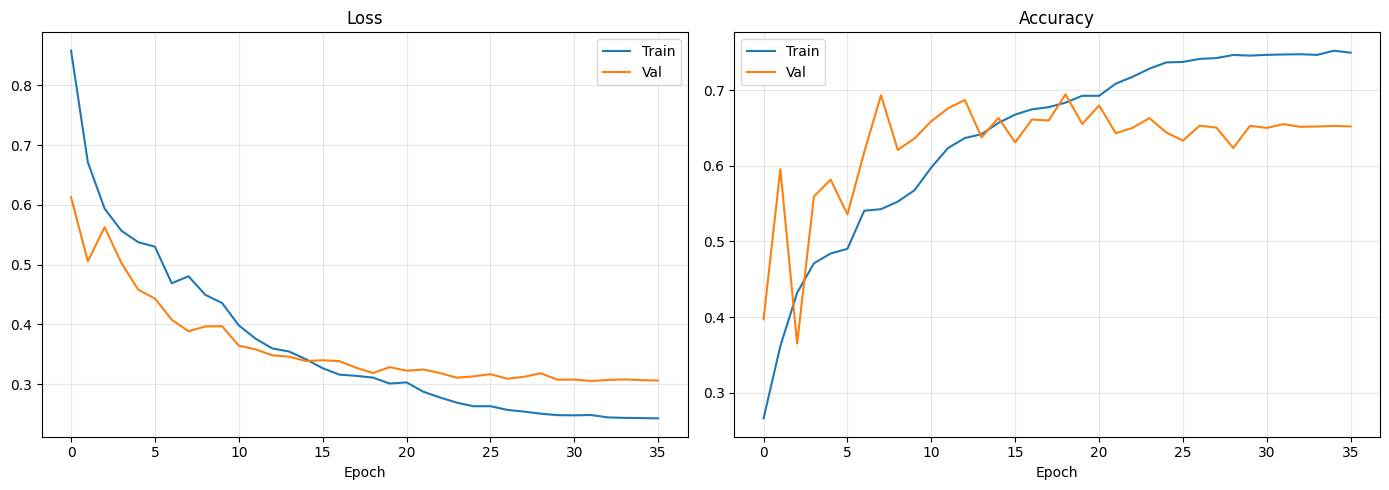

In [47]:
train_metric_key = 'accuracy' if 'accuracy' in history.history else 'ordinal_joint_accuracy'
val_metric_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_ordinal_joint_accuracy'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history[train_metric_key], label='Train')
axes[1].plot(history.history[val_metric_key], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/training_history.png', dpi=140)
plt.show()

In [48]:
present_classes = sorted(set(y_test) | set(y_pred))
target_names = [label_map[i] for i in present_classes]

report = classification_report(
    y_test,
    y_pred,
    labels=present_classes,
    target_names=target_names,
    digits=4,
    zero_division=0,
)
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

per_class_f1_dict = {
    idx: f1_score(y_test, y_pred, labels=[idx], average='macro', zero_division=0)
    for idx in range(6)
}

before_class_table = best_run['before_metrics']['class_table']
after_class_table = best_run['after_metrics']['class_table']

comparison_df = pd.DataFrame([
    {
        'Metric': 'Macro F1',
        'Before': BASELINE_MACRO_F1,
        'After': macro_f1,
        'Delta': macro_f1 - BASELINE_MACRO_F1,
    },
    {
        'Metric': 'None F1',
        'Before': float(before_class_table.loc[before_class_table.class_idx == 0, 'f1'].iloc[0]),
        'After': float(after_class_table.loc[after_class_table.class_idx == 0, 'f1'].iloc[0]),
        'Delta': float(after_class_table.loc[after_class_table.class_idx == 0, 'f1'].iloc[0] - before_class_table.loc[before_class_table.class_idx == 0, 'f1'].iloc[0]),
    },
    {
        'Metric': 'D0 F1',
        'Before': float(before_class_table.loc[before_class_table.class_idx == 1, 'f1'].iloc[0]),
        'After': float(after_class_table.loc[after_class_table.class_idx == 1, 'f1'].iloc[0]),
        'Delta': float(after_class_table.loc[after_class_table.class_idx == 1, 'f1'].iloc[0] - before_class_table.loc[before_class_table.class_idx == 1, 'f1'].iloc[0]),
    },
    {
        'Metric': 'D3 F1',
        'Before': BASELINE_D3_F1,
        'After': per_class_f1_dict[4],
        'Delta': per_class_f1_dict[4] - BASELINE_D3_F1,
    },
    {
        'Metric': 'D4 F1',
        'Before': BASELINE_D4_F1,
        'After': per_class_f1_dict[5],
        'Delta': per_class_f1_dict[5] - BASELINE_D4_F1,
    },
])

train_metric_key = 'accuracy' if 'accuracy' in history.history else 'ordinal_joint_accuracy'
val_metric_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_ordinal_joint_accuracy'
gap_last = history.history[train_metric_key][-1] - history.history[val_metric_key][-1]
gap_best = best_run['acc_gap_best']

print('=' * 70)
print('CLASSIFICATION REPORT (BEST RUN)')
print('=' * 70)
print(f"Best mode: {best_run['mode']}")
print(f"Thresholds: {best_run['thresholds']}")
print(report)
print('=' * 70)
print(f'Accuracy:    {accuracy:.4f}')
print(f'Macro F1:    {macro_f1:.4f}')
print(f'Weighted F1: {weighted_f1:.4f}')
print(f'F1 None:     {per_class_f1_dict[0]:.4f}')
print(f'F1 D0:       {per_class_f1_dict[1]:.4f}')
print(f'F1 D3:       {per_class_f1_dict[4]:.4f}')
print(f'F1 D4:       {per_class_f1_dict[5]:.4f}')
print(f'Train-val gap (last epoch): {gap_last:.4f}')
print(f'Train-val gap (best val_loss epoch): {gap_best:.4f}')
print('=' * 70)

print('\nDominant confusion pairs (before):')
for src, dst, cnt in best_run['dominant_pairs_before']:
    if cnt <= 0:
        continue
    print(f'  {label_map[src]} -> {label_map[dst]}: {cnt}')

print('\nDominant confusion pairs (after):')
for src, dst, cnt in best_run['dominant_pairs_after']:
    if cnt <= 0:
        continue
    print(f'  {label_map[src]} -> {label_map[dst]}: {cnt}')

print('\nRolling-threshold CV diagnostics:')
display(best_run['cv_threshold_diag'])

print('\nPer-class precision/recall/F1 (after):')
display(best_run['class_table'])

print('\nBefore vs After:')
display(comparison_df)

CLASSIFICATION REPORT (BEST RUN)
Best mode: boundary_ce
Thresholds: {0: 0.8, 1: 1.25, 2: 1.2, 4: 0.8, 5: 0.35}
              precision    recall  f1-score   support

        None     0.7880    0.6970    0.7397      4287
          D0     0.5741    0.6241    0.5981      3512
          D1     0.7298    0.8329    0.7780      3298
          D2     0.7883    0.6459    0.7100      1395
          D3     0.8421    0.7479    0.7922       706
          D4     0.8615    0.9598    0.9080       473

    accuracy                         0.7176     13671
   macro avg     0.7640    0.7513    0.7543     13671
weighted avg     0.7244    0.7176    0.7181     13671

Accuracy:    0.7176
Macro F1:    0.7543
Weighted F1: 0.7181
F1 None:     0.7397
F1 D0:       0.5981
F1 D3:       0.7922
F1 D4:       0.9080
Train-val gap (last epoch): 0.0974
Train-val gap (best val_loss epoch): 0.0920

Dominant confusion pairs (before):
  None -> D0: 1236
  D0 -> None: 783
  D0 -> D1: 530
  D2 -> D1: 420
  D1 -> D0: 390
  D1 -

,fold,eval_start,eval_end,macro_f1,pair_err_01,pair_err_12,objective
0,1,2021-10-26,2021-12-21,0.634798,0.470263,0.101887,0.538436
1,2,2021-12-28,2022-02-22,0.569302,0.472296,0.150980,0.475555
2,3,2022-03-01,2022-04-26,0.565830,0.567742,0.264000,0.515907
3,4,2022-05-03,2022-06-28,0.704981,0.412776,0.114679,0.720318
4,5,2022-07-05,2022-08-30,0.693665,0.421652,0.147059,0.696031
5,6,2022-09-06,2022-11-01,0.640564,0.148649,0.120968,0.730865
6,7,2022-11-08,2023-01-03,0.848265,0.000000,0.032051,1.003318
7,8,2023-01-10,2023-03-07,0.692300,0.357843,0.091286,0.738743



Per-class precision/recall/F1 (after):


,class_idx,class_name,precision,recall,f1,support
0,0,None,0.787975,0.696991,0.739696,4287
1,1,D0,0.574123,0.624146,0.598090,3512
2,2,D1,0.729809,0.832929,0.777967,3298
3,3,D2,0.788276,0.645878,0.710008,1395
4,4,D3,0.842105,0.747875,0.792198,706
5,5,D4,0.861480,0.959831,0.908000,473



Before vs After:


,Metric,Before,After,Delta
0,Macro F1,0.590000,0.754326,0.164326
1,None F1,0.739696,0.739696,0.000000
2,D0 F1,0.598090,0.598090,0.000000
3,D3 F1,0.270000,0.792198,0.522198
4,D4 F1,0.000000,0.908000,0.908000


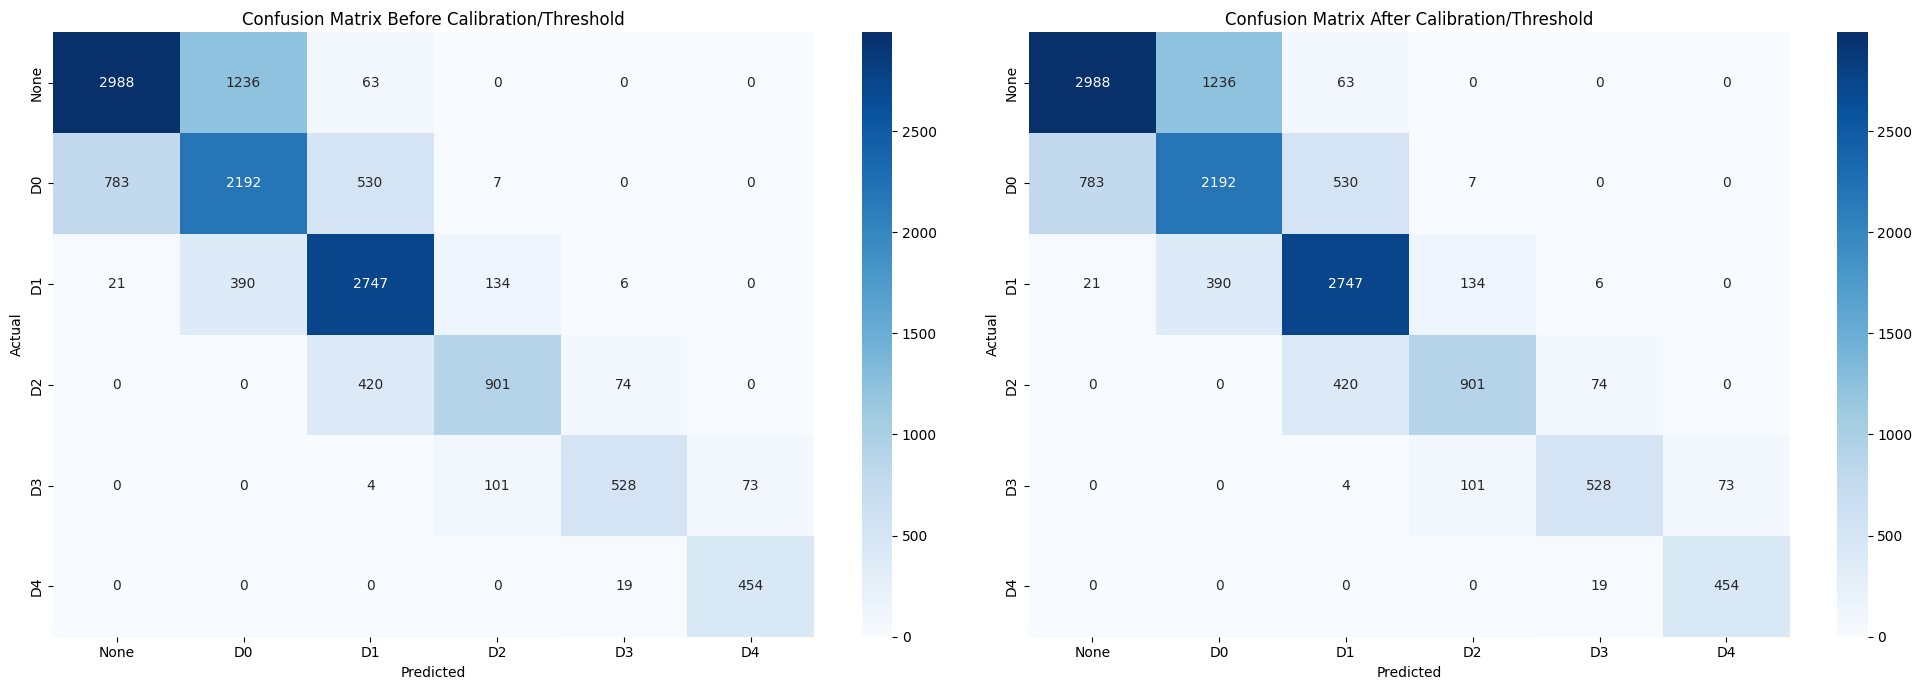

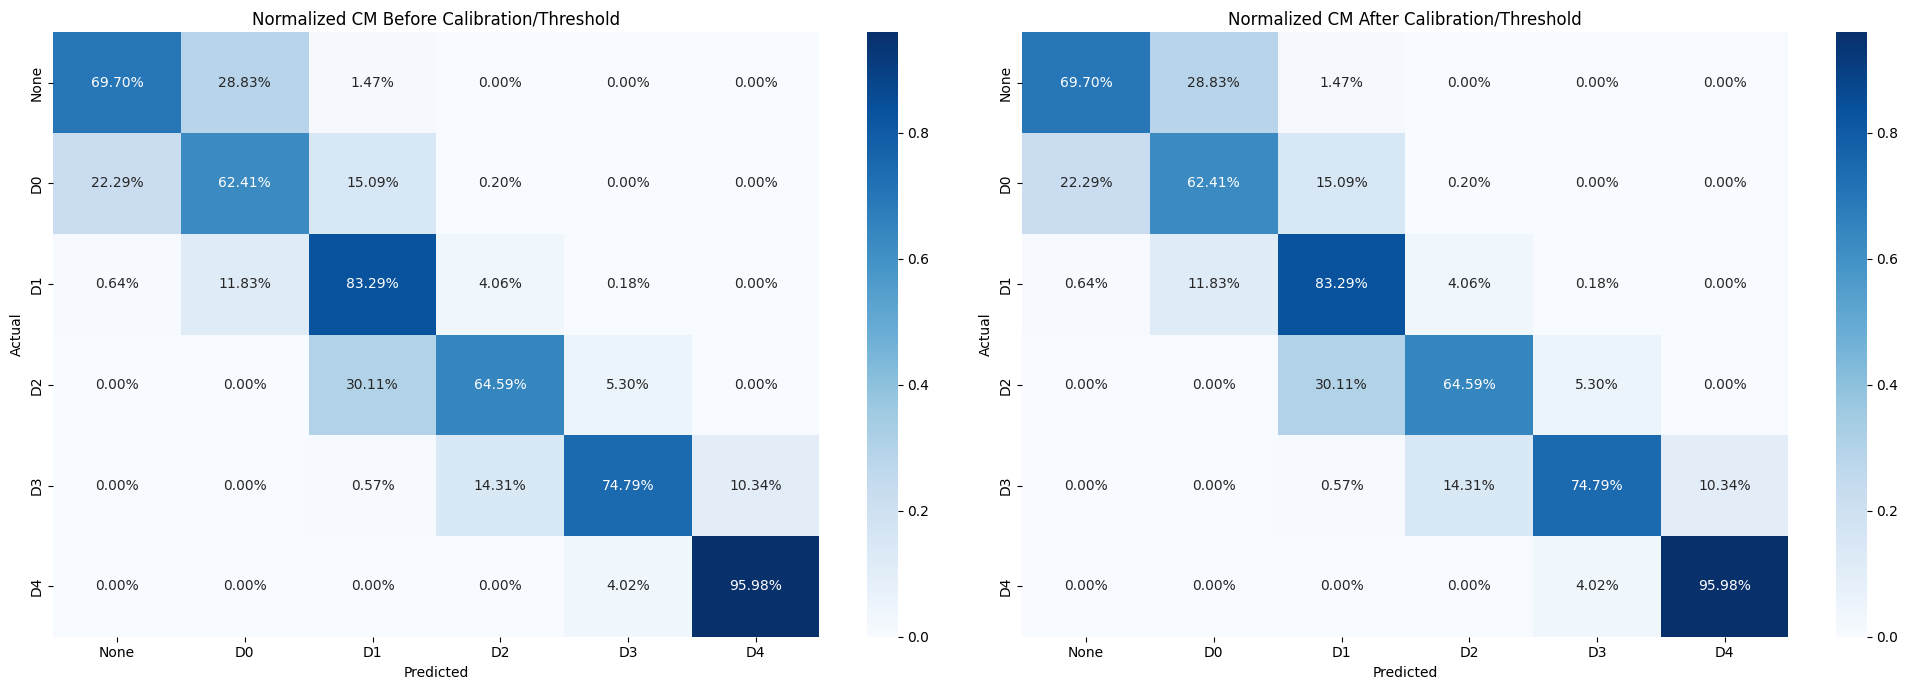

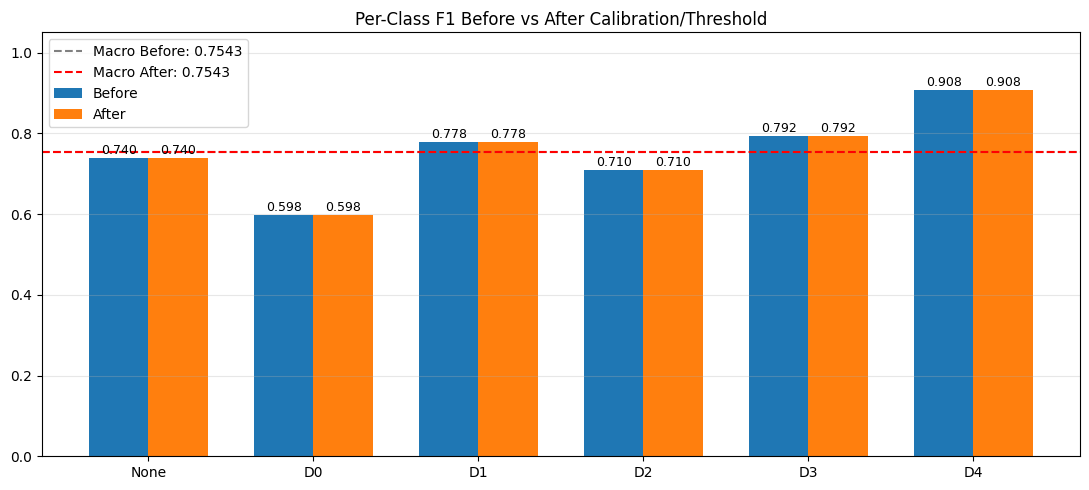

In [49]:
num_classes = 6
labels_idx = list(range(num_classes))

cm_before = best_run['cm_before']
cm_after = best_run['cm_after']

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_map[i] for i in labels_idx],
            yticklabels=[label_map[i] for i in labels_idx],
            ax=axes[0])
axes[0].set_title('Confusion Matrix Before Calibration/Threshold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_map[i] for i in labels_idx],
            yticklabels=[label_map[i] for i in labels_idx],
            ax=axes[1])
axes[1].set_title('Confusion Matrix After Calibration/Threshold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/confusion_matrix_before_after_counts.png', dpi=140)
plt.show()

cm_before_norm = cm_before.astype(float) / cm_before.sum(axis=1, keepdims=True)
cm_before_norm = np.nan_to_num(cm_before_norm)
cm_after_norm = cm_after.astype(float) / cm_after.sum(axis=1, keepdims=True)
cm_after_norm = np.nan_to_num(cm_after_norm)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(cm_before_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=[label_map[i] for i in labels_idx],
            yticklabels=[label_map[i] for i in labels_idx],
            ax=axes[0])
axes[0].set_title('Normalized CM Before Calibration/Threshold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_after_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=[label_map[i] for i in labels_idx],
            yticklabels=[label_map[i] for i in labels_idx],
            ax=axes[1])
axes[1].set_title('Normalized CM After Calibration/Threshold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/confusion_matrix_before_after_normalized.png', dpi=140)
plt.show()

per_class_f1_before = best_run['before_metrics']['class_table']['f1'].values
per_class_f1_after = best_run['after_metrics']['class_table']['f1'].values
x = np.arange(num_classes)
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width / 2, per_class_f1_before, width=width, label='Before')
ax.bar(x + width / 2, per_class_f1_after, width=width, label='After')

for i, (b, a) in enumerate(zip(per_class_f1_before, per_class_f1_after)):
    ax.text(i - width / 2, b + 0.01, f'{b:.3f}', ha='center', fontsize=9)
    ax.text(i + width / 2, a + 0.01, f'{a:.3f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([label_map[i] for i in labels_idx])
ax.axhline(best_run['test_macro_raw'], color='gray', linestyle='--', label=f"Macro Before: {best_run['test_macro_raw']:.4f}")
ax.axhline(best_run['test_macro_after'], color='red', linestyle='--', label=f"Macro After: {best_run['test_macro_after']:.4f}")
ax.set_ylim(0, 1.05)
ax.set_title('Per-Class F1 Before vs After Calibration/Threshold')
ax.grid(alpha=0.3, axis='y')
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/per_class_f1_before_after.png', dpi=140)
plt.show()

In [50]:
summary_path = f'{OUTPUT_FOLDER}/results_summary.txt'
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write('BiLSTM Weekly Kansas Clean - Boundary and Calibration Optimization\n')
    f.write(f'Best mode: {best_run["mode"]}\n')
    f.write(f'Selected variant: {best_run["selected_variant"]}\n')
    f.write(f'Thresholds: {best_run["thresholds"]}\n')
    f.write(f'Calibration: {CALIBRATION_METHOD}\n')
    f.write(f'Rolling folds: {ROLLING_FOLDS}\n')
    f.write('Imbalance handling: class_weight only (no ROS)\n')
    f.write(f'Seq Length: {SEQ_LENGTH}\n')
    f.write(f'Accuracy (after): {accuracy:.4f}\n')
    f.write(f'Macro F1 (after): {macro_f1:.4f}\n')
    f.write(f'Weighted F1 (after): {weighted_f1:.4f}\n')
    f.write(f'F1 None (after): {per_class_f1_dict[0]:.4f}\n')
    f.write(f'F1 D0 (after): {per_class_f1_dict[1]:.4f}\n')
    f.write(f'F1 D3 (after): {per_class_f1_dict[4]:.4f}\n')
    f.write(f'F1 D4 (after): {per_class_f1_dict[5]:.4f}\n\n')

    f.write(f'Macro F1 raw argmax: {best_run["test_macro_raw"]:.4f}\n')
    f.write(f'Macro F1 calibrated+thresholded: {best_run["test_macro_calibrated"]:.4f}\n')
    f.write(f'Macro F1 selected final: {best_run["test_macro_after"]:.4f}\n')
    f.write(f'Macro F1 delta (selected final vs raw): {best_run["test_macro_after"] - best_run["test_macro_raw"]:+.4f}\n\n')

    f.write('Before vs After against historical baseline:\n')
    for _, row in comparison_df.iterrows():
        f.write(f"  {row['Metric']}: before={row['Before']:.4f}, after={row['After']:.4f}, delta={row['Delta']:+.4f}\n")

    f.write('\nTop confusion pairs before:\n')
    for src, dst, cnt in best_run['dominant_pairs_before']:
        f.write(f'  {label_map[src]} -> {label_map[dst]}: {cnt}\n')

    f.write('\nTop confusion pairs after:\n')
    for src, dst, cnt in best_run['dominant_pairs_after']:
        f.write(f'  {label_map[src]} -> {label_map[dst]}: {cnt}\n')

    f.write('\nRolling-threshold CV diagnostics:\n')
    if len(best_run['cv_threshold_diag']) == 0:
        f.write('  (no rolling folds available)\n')
    else:
        for _, row in best_run['cv_threshold_diag'].iterrows():
            f.write(
                f"  Fold {int(row['fold'])} ({row['eval_start']} to {row['eval_end']}): "
                f"macro={row['macro_f1']:.4f}, pair01={row['pair_err_01']:.4f}, "
                f"pair12={row['pair_err_12']:.4f}, obj={row['objective']:.4f}\n"
            )

    f.write('\nPer-class F1 (after):\n')
    for i in range(num_classes):
        f.write(f'  {label_map[i]}: {per_class_f1_dict[i]:.4f}\n')

    f.write('\nClassification Report (after):\n')
    f.write(report)

print(f'Results saved to {summary_path}')

Results saved to output_weekly_kansas_clean_expC_recover/results_summary.txt
